<a href="https://colab.research.google.com/github/Bhushan-M109/EDX-LEARNING-ANALYTICS-DASHBOARD/blob/main/COVID_19_Global_EDA_(Feb_2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Global Statistics – EDA (Feb 2026)

**Goals:** Validate data quality • Separate country vs aggregate rows • Engineer indicators • Publication-ready visuals



## 1) Environment Setup

In [2]:
from pathlib import Path
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px

warnings.filterwarnings("ignore")

# Display setup
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visualization setup
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (14, 7),
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})

PALETTE = "viridis"


def human_number(value):
    """Format large numbers for annotation and KPI tables."""
    if pd.isna(value):
        return np.nan
    if abs(value) >= 1_000_000_000:
        return f"{value / 1_000_000_000:.2f}B"
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    if abs(value) >= 1_000:
        return f"{value / 1_000:.2f}K"
    return f"{value:.2f}"


## 2) Data Load & Audit

In [6]:
DATA_PATH = Path("//content/covid19_global_statistics_2026.csv")
assert DATA_PATH.exists(), f"Dataset not found at: {DATA_PATH.resolve()}"

raw_df = pd.read_csv(DATA_PATH)
df = raw_df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print(f"Report date(s): {df['date'].dt.date.nunique()} unique -> {sorted(df['date'].dt.date.dropna().unique())[:3]}")

df.head(8)


Rows: 238 | Columns: 13
Report date(s): 1 unique -> [datetime.date(2026, 2, 16)]


,continent,country,population,date,new_cases,active_cases,cases_per_million,total_cases,new_deaths,deaths_per_million,total_deaths,tests_per_million,total_tests
0,Africa,Eritrea,"3,662,244.00",2026-02-16,NaN,0.00,"2,782.00",10189,NaN,28.00,103.00,"6,470.00","23,693.00"
1,Africa,Niger,"26,083,660.00",2026-02-16,NaN,729.00,381.00,9931,NaN,12.00,312.00,"9,759.00","254,538.00"
2,Africa,Saint-Helena,"6,115.00",2026-02-16,NaN,"2,164.00","354,211.00",2166,NaN,NaN,NaN,NaN,NaN
3,South-America,Falkland-Islands,"3,539.00",2026-02-16,NaN,0.00,"545,352.00",1930,NaN,NaN,NaN,"2,439,107.00","8,632.00"
4,North-America,Montserrat,"4,965.00",2026-02-16,NaN,19.00,"282,578.00",1403,NaN,"1,611.00",8.00,"3,577,442.00","17,762.00"
5,NaN,Diamond-Princess,NaN,2026-02-16,NaN,0.00,NaN,712,NaN,NaN,13.00,NaN,NaN
6,Europe,Vatican-City,799.00,2026-02-16,NaN,0.00,"36,295.00",29,NaN,NaN,NaN,NaN,NaN
7,Africa,Western-Sahara,"626,161.00",2026-02-16,NaN,0.00,16.00,10,NaN,2.00,1.00,NaN,NaN


In [7]:
schema_audit = (
    pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })
    .sort_values(["missing_pct", "n_unique"], ascending=[False, False])
)

schema_audit


,dtype,non_null,missing_pct,n_unique
new_deaths,float64,3,98.74,3
new_cases,float64,17,92.86,13
active_cases,float64,191,19.75,158
tests_per_million,float64,213,10.50,213
total_tests,float64,213,10.50,212
deaths_per_million,float64,225,5.46,211
population,float64,229,3.78,229
cases_per_million,float64,230,3.36,229
total_deaths,float64,233,2.10,218
continent,object,236,0.84,7


## 3) Entity Modeling

Data mixes entities: **world** (All), **continent totals**, **ships** (Diamond-Princess, MS-Zaandam), and **countries**. Rankings below use country rows only.


In [8]:
continents = set(df["continent"].dropna().unique())
ships = {"Diamond-Princess", "MS-Zaandam"}

conditions = [
    df["country"].eq("All"),
    df["country"].isin(continents),
    df["country"].isin(ships),
]
choices = ["world", "continent_total", "ship"]

df["entity_type"] = np.select(conditions, choices, default="country")

country_df = df.loc[df["entity_type"].eq("country")].copy()
aggregate_df = df.loc[df["entity_type"].ne("country")].copy()

entity_counts = df["entity_type"].value_counts().rename_axis("entity_type").to_frame("rows")
entity_counts["pct_of_dataset"] = (entity_counts["rows"] / len(df) * 100).round(2)

entity_counts


,rows,pct_of_dataset
entity_type,,
country,229,96.22
continent_total,6,2.52
ship,2,0.84
world,1,0.42


## 4) Data Quality

In [9]:
quality_checks = {
    "duplicate_country_rows": int(country_df["country"].duplicated().sum()),
    "negative_numeric_values": int((country_df.select_dtypes(include=["number"]) < 0).sum().sum()),
    "rows_total_deaths_gt_total_cases": int((country_df["total_deaths"] > country_df["total_cases"]).fillna(False).sum()),
    "rows_active_cases_gt_total_cases": int((country_df["active_cases"] > country_df["total_cases"]).fillna(False).sum()),
    "rows_missing_continent": int(country_df["continent"].isna().sum()),
    "rows_missing_population": int(country_df["population"].isna().sum()),
}

pd.Series(quality_checks, name="value").to_frame()


,value
duplicate_country_rows,0
negative_numeric_values,0
rows_total_deaths_gt_total_cases,0
rows_active_cases_gt_total_cases,0
rows_missing_continent,0
rows_missing_population,0


,missing_pct
new_deaths,99.13
new_cases,93.01
active_cases,20.52
tests_per_million,6.99
total_tests,6.99
deaths_per_million,2.18
total_deaths,2.18
date,0.00
continent,0.00
country,0.00


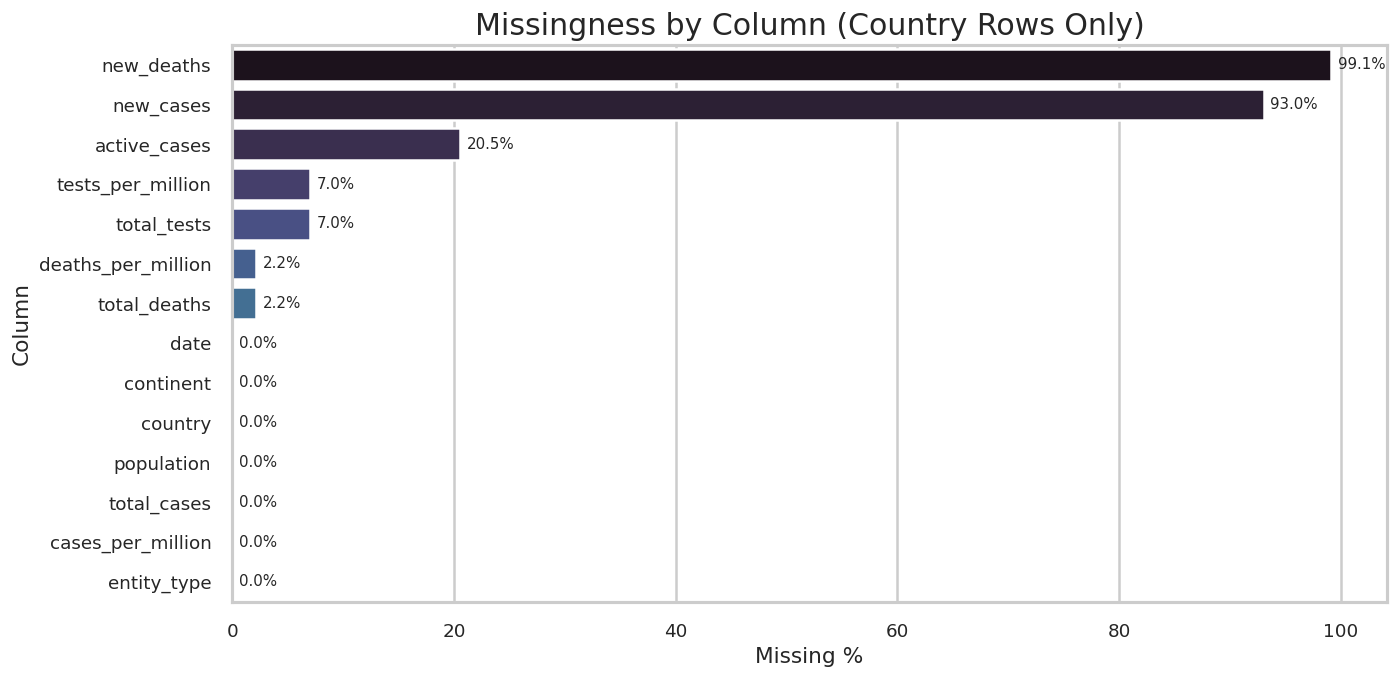

In [10]:
missing_pct_country = (
    country_df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_pct")
    .to_frame()
)

display(missing_pct_country)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=missing_pct_country.reset_index(),
    y="index",
    x="missing_pct",
    palette="mako",
)
ax.set_title("Missingness by Column (Country Rows Only)")
ax.set_xlabel("Missing %")
ax.set_ylabel("Column")
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.1f}%", (width + 0.6, p.get_y() + p.get_height() / 2), va="center", fontsize=9)
plt.xlim(0, max(100, missing_pct_country["missing_pct"].max() + 5))
plt.tight_layout()
plt.show()


## 5) Feature Engineering

In [11]:
country_df["cfr"] = np.where(
    country_df["total_cases"] > 0,
    country_df["total_deaths"] / country_df["total_cases"],
    np.nan,
)
country_df["cfr_pct"] = country_df["cfr"] * 100
country_df["cases_per_100k"] = country_df["cases_per_million"] / 10
country_df["deaths_per_100k"] = country_df["deaths_per_million"] / 10
country_df["tests_per_case"] = np.where(
    country_df["total_cases"] > 0,
    country_df["total_tests"] / country_df["total_cases"],
    np.nan,
)

kpis = {
    "country_rows": len(country_df),
    "countries": int(country_df["country"].nunique()),
    "continents": int(country_df["continent"].nunique()),
    "global_cases_country_sum": country_df["total_cases"].sum(),
    "global_deaths_country_sum": country_df["total_deaths"].sum(skipna=True),
    "median_country_cfr_pct": country_df["cfr_pct"].median(skipna=True),
}

pd.DataFrame({
    "metric": list(kpis.keys()),
    "value": list(kpis.values()),
    "formatted": [human_number(v) if isinstance(v, (int, float, np.integer, np.floating)) else v for v in kpis.values()],
})


,metric,value,formatted
0,country_rows,229.00,229.00
1,countries,229.00,229.00
2,continents,6.00,6.00
3,global_cases_country_sum,"704,753,169.00",704.75M
4,global_deaths_country_sum,"7,010,666.00",7.01M
5,median_country_cfr_pct,0.90,0.90


## 6) Distribution Analysis

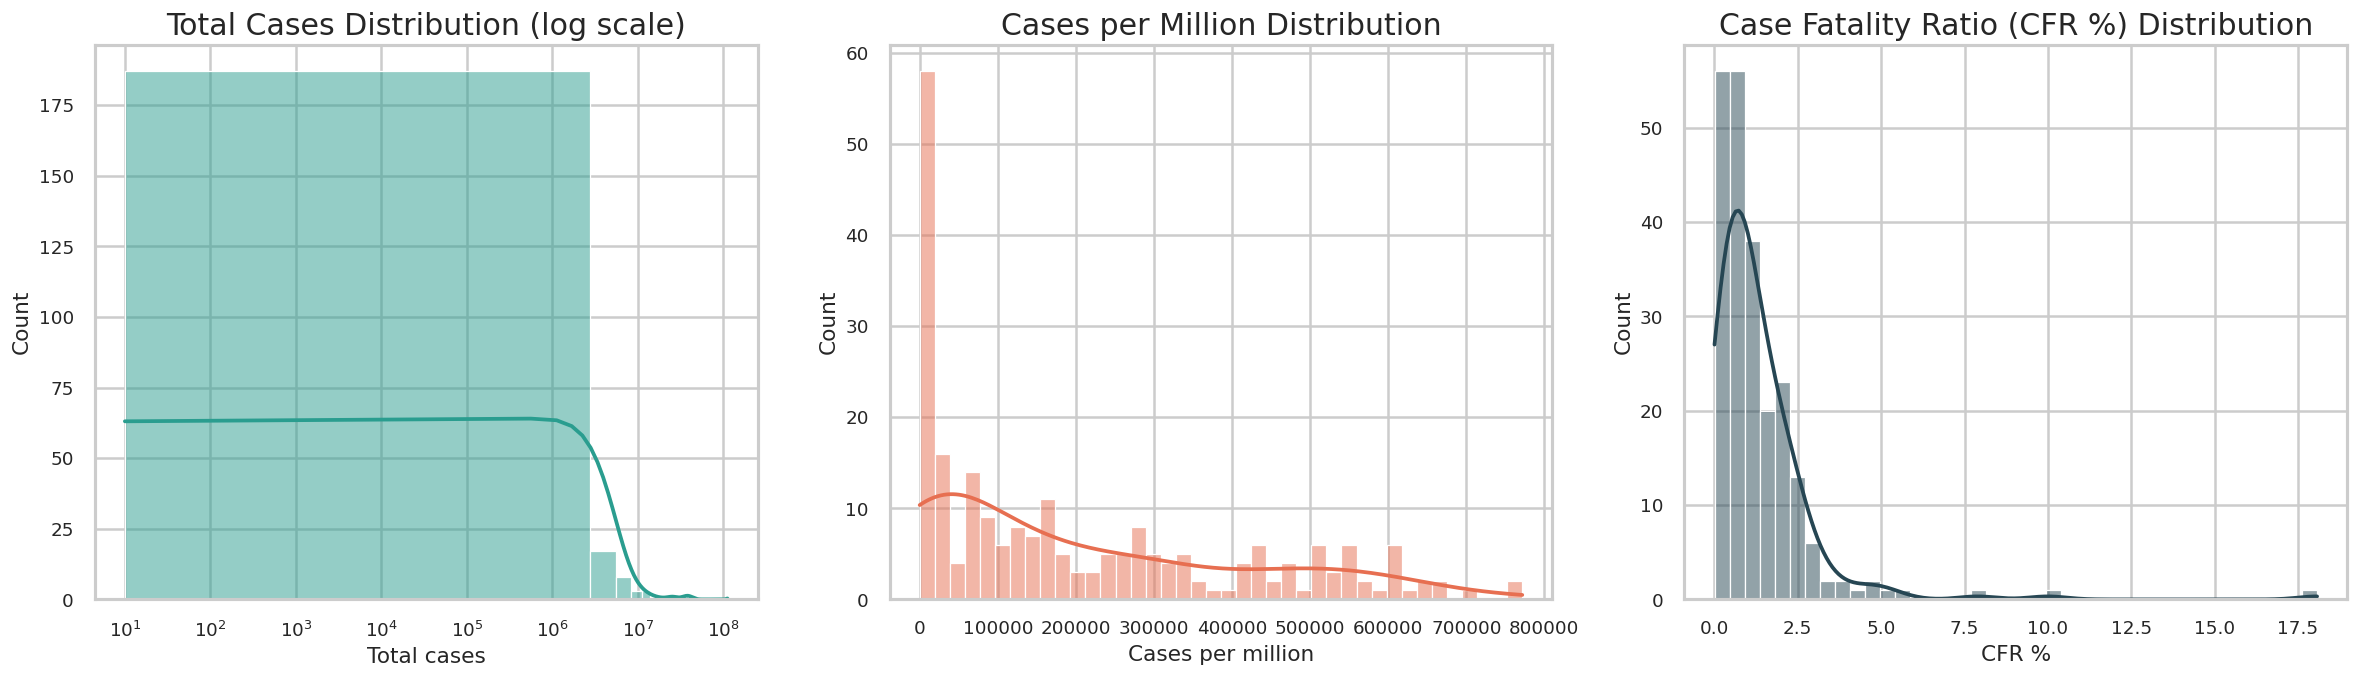

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(country_df["total_cases"], bins=40, kde=True, ax=axes[0], color="#2A9D8F")
axes[0].set_xscale("log")
axes[0].set_title("Total Cases Distribution (log scale)")
axes[0].set_xlabel("Total cases")

sns.histplot(country_df["cases_per_million"], bins=40, kde=True, ax=axes[1], color="#E76F51")
axes[1].set_title("Cases per Million Distribution")
axes[1].set_xlabel("Cases per million")

sns.histplot(country_df["cfr_pct"].dropna(), bins=40, kde=True, ax=axes[2], color="#264653")
axes[2].set_title("Case Fatality Ratio (CFR %) Distribution")
axes[2].set_xlabel("CFR %")

plt.tight_layout()
plt.show()


## 7) Country Rankings

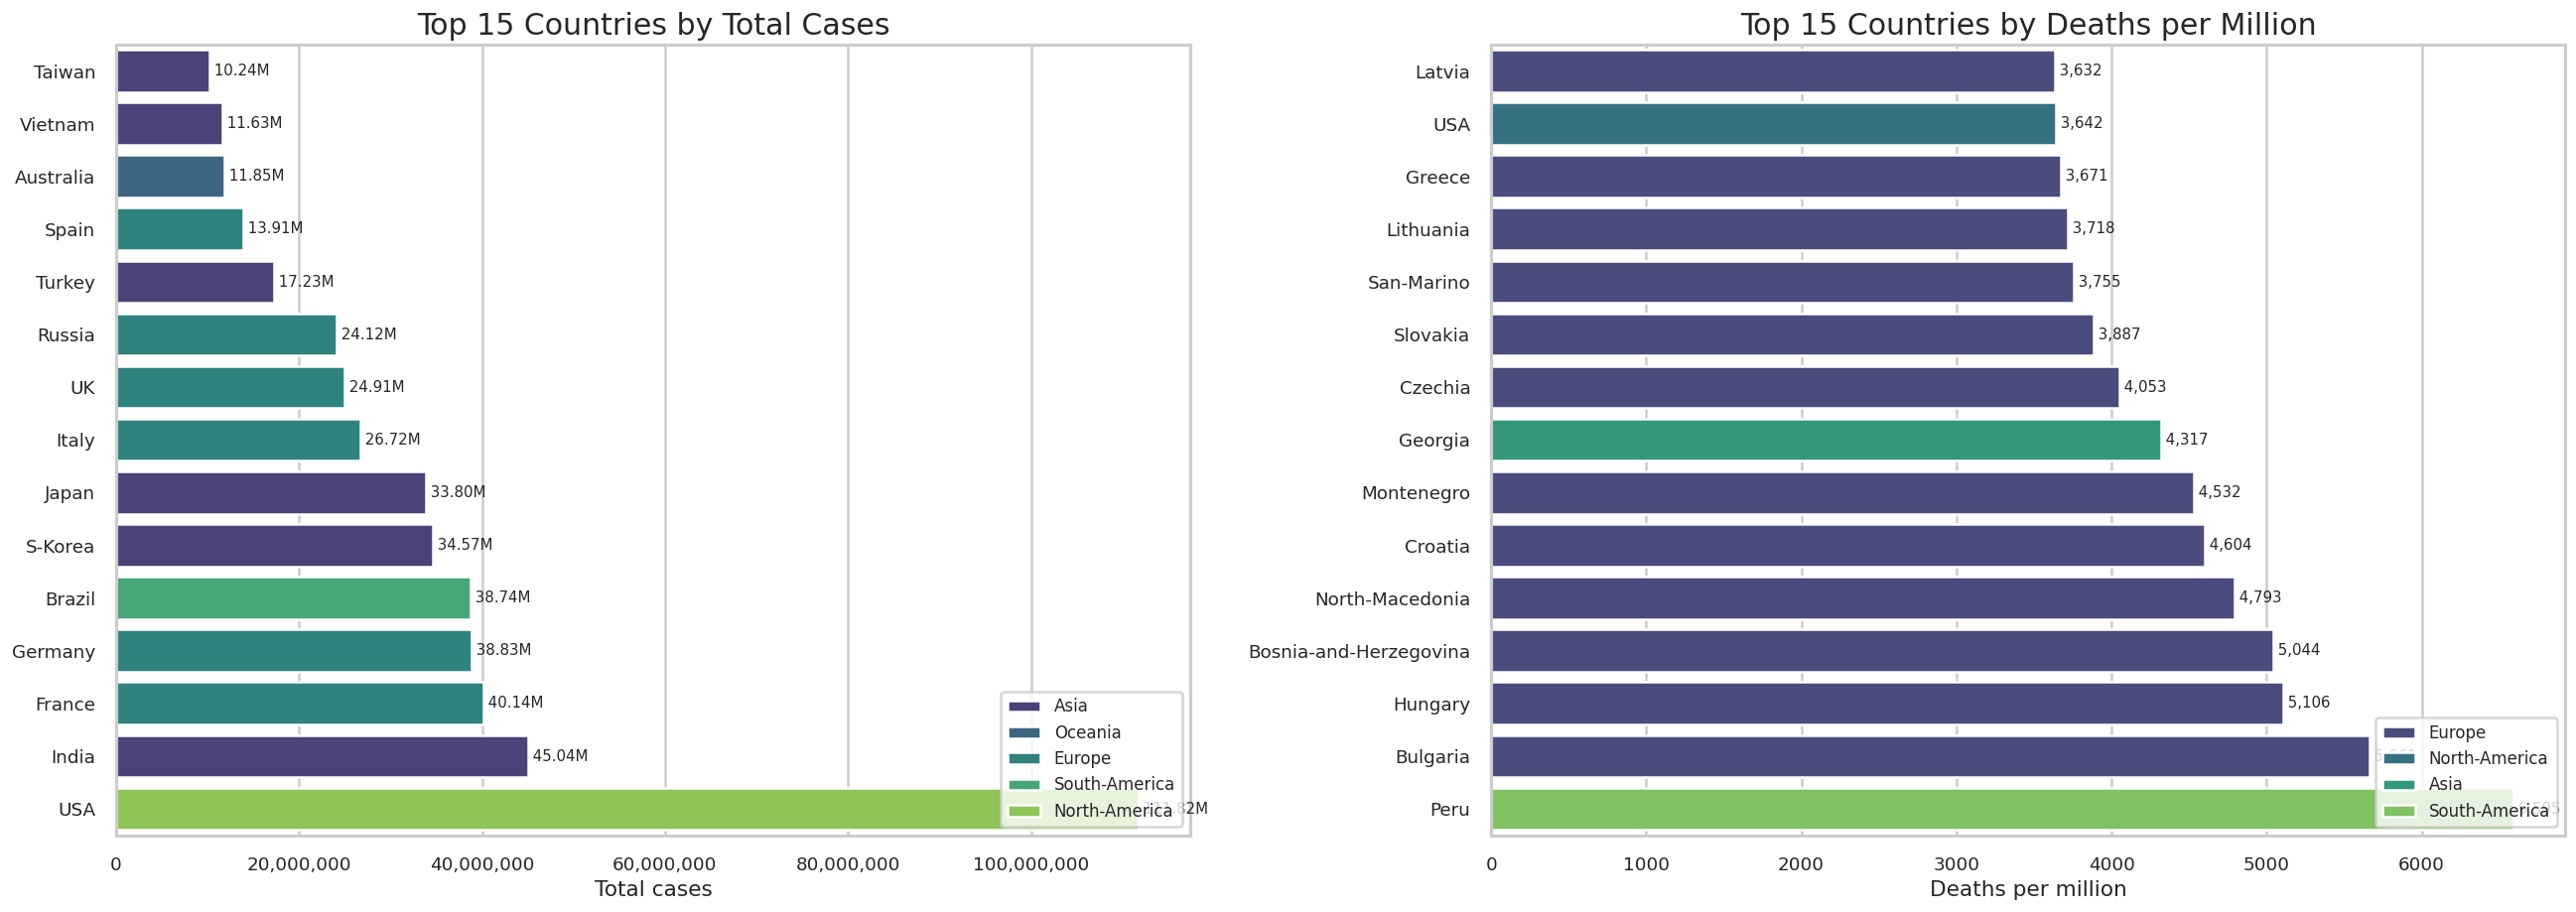

In [13]:
top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

top_cases = country_df.nlargest(top_n, "total_cases").sort_values("total_cases")
sns.barplot(data=top_cases, x="total_cases", y="country", hue="continent", dodge=False, ax=axes[0], palette=PALETTE)
axes[0].set_title(f"Top {top_n} Countries by Total Cases")
axes[0].set_xlabel("Total cases")
axes[0].xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
axes[0].set_ylabel("")

for i, v in enumerate(top_cases["total_cases"]):
    axes[0].text(v, i, f" {human_number(v)}", va="center", fontsize=9)

# Use normalized mortality burden to compare countries with different populations
top_death_rate = country_df.dropna(subset=["deaths_per_million"]).nlargest(top_n, "deaths_per_million").sort_values("deaths_per_million")
sns.barplot(data=top_death_rate, x="deaths_per_million", y="country", hue="continent", dodge=False, ax=axes[1], palette=PALETTE)
axes[1].set_title(f"Top {top_n} Countries by Deaths per Million")
axes[1].set_xlabel("Deaths per million")
axes[1].set_ylabel("")

for i, v in enumerate(top_death_rate["deaths_per_million"]):
    axes[1].text(v, i, f" {v:,.0f}", va="center", fontsize=9)

for ax in axes:
    ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()


## 8) Continent-Level Summary

Population-weighted metrics across country rows.


In [14]:
continent_summary = (
    country_df.groupby("continent", as_index=False)
    .agg(
        countries=("country", "nunique"),
        population=("population", "sum"),
        total_cases=("total_cases", "sum"),
        total_deaths=("total_deaths", "sum"),
        total_tests=("total_tests", "sum"),
    )
)

continent_summary["cases_per_100k_weighted"] = continent_summary["total_cases"] / continent_summary["population"] * 100_000
continent_summary["deaths_per_100k_weighted"] = continent_summary["total_deaths"] / continent_summary["population"] * 100_000
continent_summary["cfr_pct_weighted"] = continent_summary["total_deaths"] / continent_summary["total_cases"] * 100
continent_summary["tests_per_case"] = continent_summary["total_tests"] / continent_summary["total_cases"]

continent_summary.sort_values("cases_per_100k_weighted", ascending=False)


,continent,countries,population,total_cases,total_deaths,total_tests,cases_per_100k_weighted,deaths_per_100k_weighted,cfr_pct_weighted,tests_per_case
4,Oceania,20,"43,470,408.00",14895771,"33,015.00","91,668,192.00","34,266.46",75.95,0.22,6.15
2,Europe,48,"747,543,837.00",253406198,"2,101,824.00","2,848,046,702.00","33,898.51",281.16,0.83,11.24
3,North-America,39,"598,140,916.00",131889132,"1,695,941.00","1,325,710,449.00","22,049.84",283.54,1.29,10.05
5,South-America,14,"437,694,443.00",70200879,"1,367,332.00","245,395,353.00","16,038.79",312.39,1.95,3.50
1,Asia,50,"4,711,356,783.00",221500265,"1,553,662.00","2,404,652,039.00","4,701.41",32.98,0.70,10.86
0,Africa,58,"1,406,728,744.00",12860924,"258,892.00","111,032,578.00",914.24,18.40,2.01,8.63


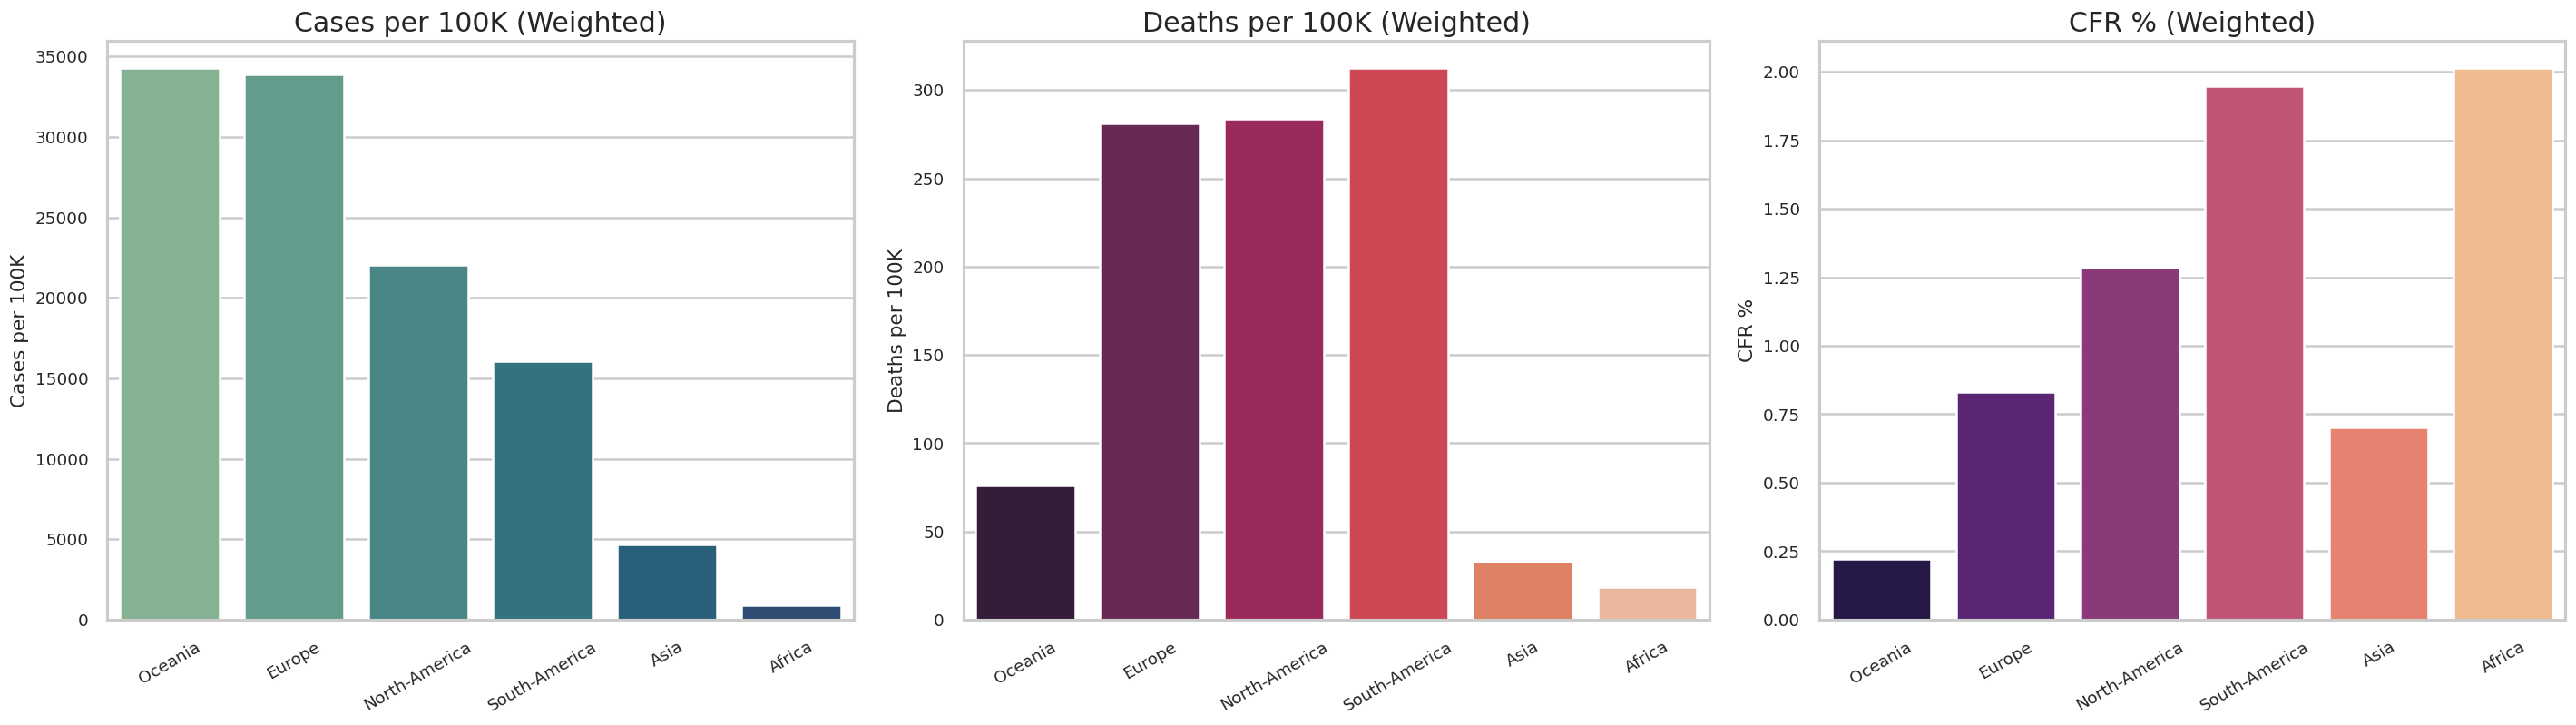

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
order = continent_summary.sort_values("cases_per_100k_weighted", ascending=False)["continent"]

sns.barplot(data=continent_summary, x="continent", y="cases_per_100k_weighted", order=order, palette="crest", ax=axes[0])
axes[0].set_title("Cases per 100K (Weighted)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Cases per 100K")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=continent_summary, x="continent", y="deaths_per_100k_weighted", order=order, palette="rocket", ax=axes[1])
axes[1].set_title("Deaths per 100K (Weighted)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Deaths per 100K")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=continent_summary, x="continent", y="cfr_pct_weighted", order=order, palette="magma", ax=axes[2])
axes[2].set_title("CFR % (Weighted)")
axes[2].set_xlabel("")
axes[2].set_ylabel("CFR %")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 9) Multivariate Risk Lens

Bubble size = population. Log scales for outlier robustness.


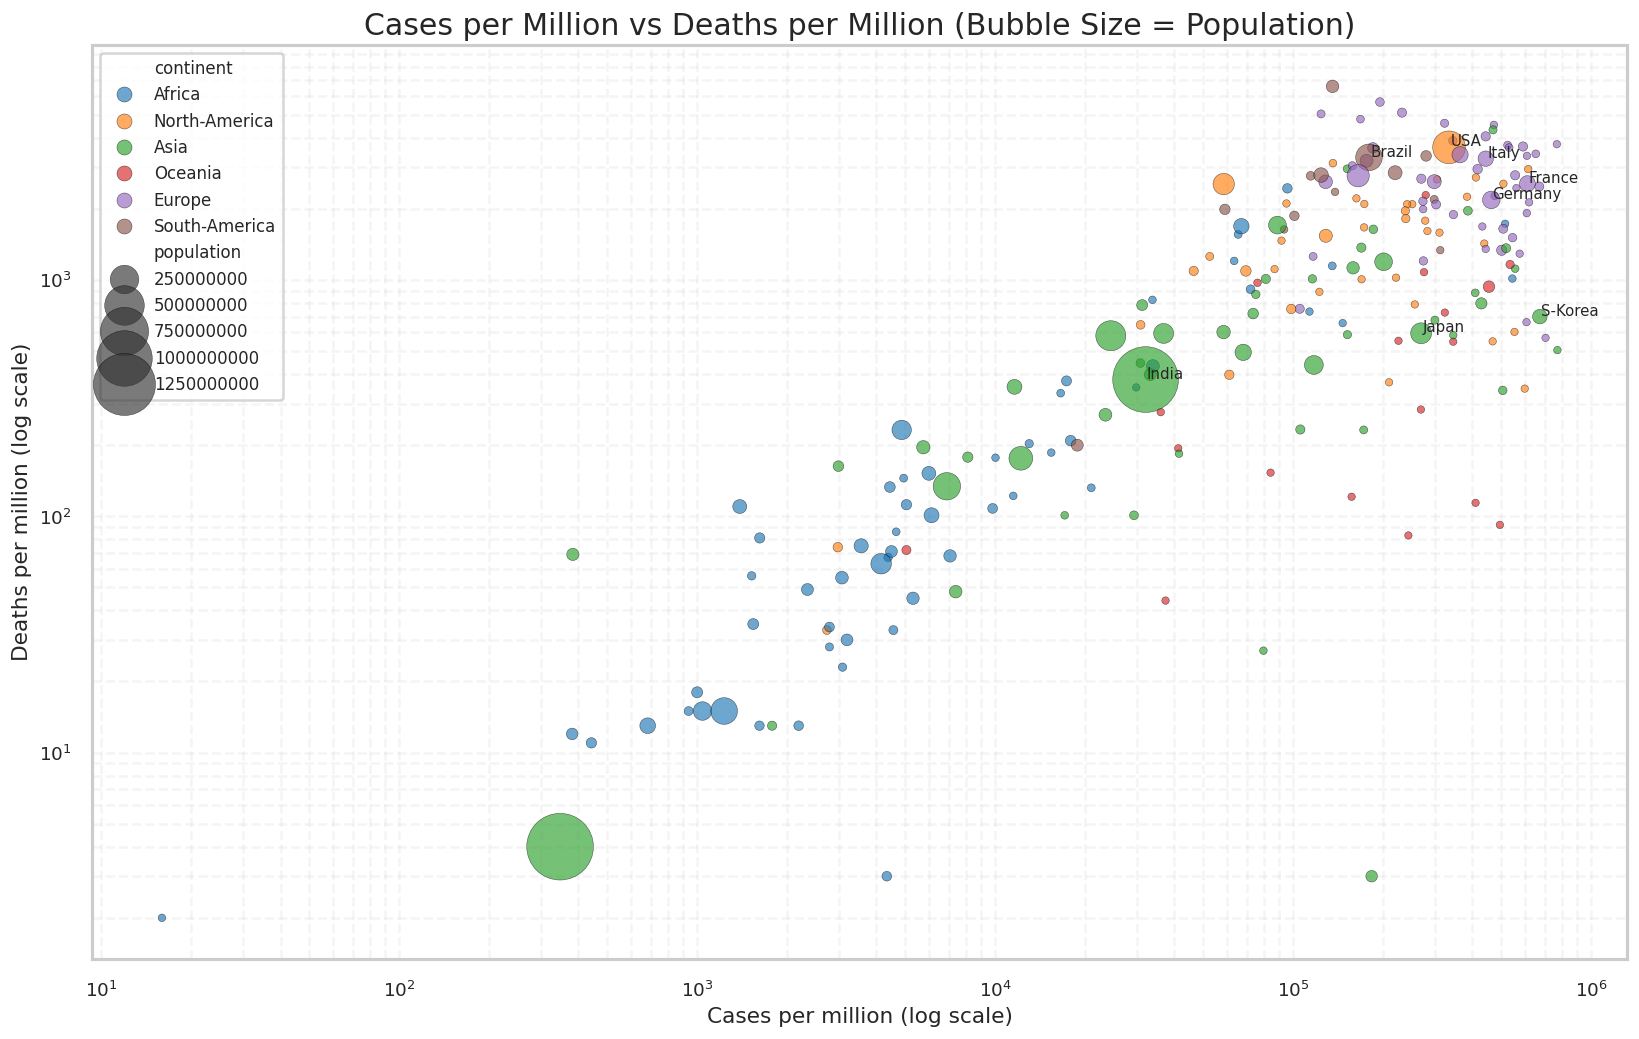

In [16]:
viz_df = country_df.dropna(subset=["cases_per_million", "deaths_per_million", "population"]).copy()

fig, ax = plt.subplots(figsize=(14, 9))
scatter = sns.scatterplot(
    data=viz_df,
    x="cases_per_million",
    y="deaths_per_million",
    size="population",
    sizes=(20, 1600),
    hue="continent",
    alpha=0.65,
    palette="tab10",
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Cases per Million vs Deaths per Million (Bubble Size = Population)")
ax.set_xlabel("Cases per million (log scale)")
ax.set_ylabel("Deaths per million (log scale)")
ax.grid(True, which="both", linestyle="--", alpha=0.2)

# Annotate a few high-impact points to improve chart readability for stakeholders.
annot = viz_df.nlargest(8, "total_cases")
for _, row in annot.iterrows():
    ax.text(row["cases_per_million"] * 1.01, row["deaths_per_million"] * 1.01, row["country"], fontsize=9)

plt.tight_layout()
plt.show()


## 10) Correlation Structure

Spearman correlation (heavy-tailed metrics).


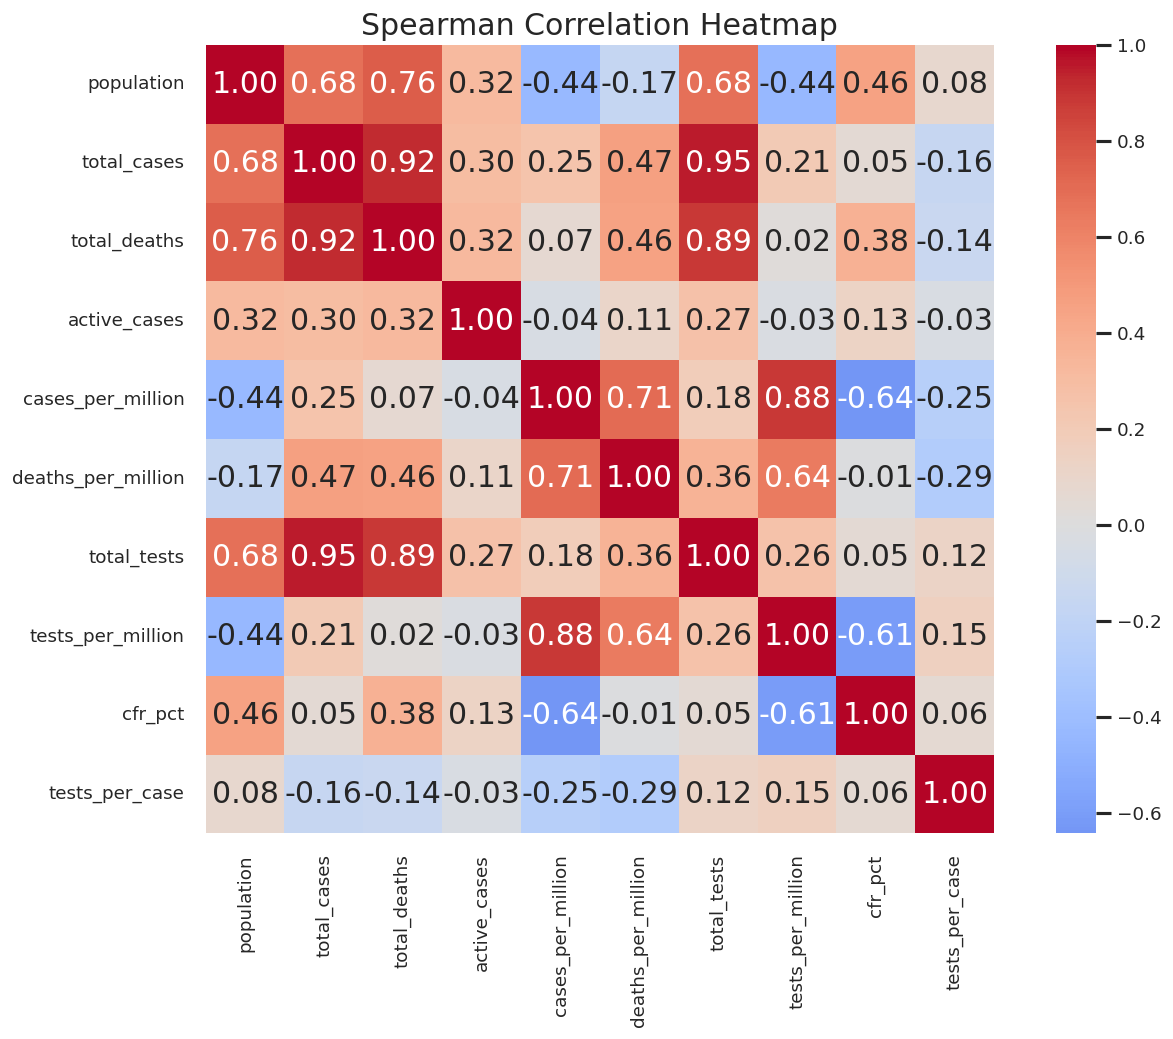

In [17]:
corr_cols = [
    "population",
    "total_cases",
    "total_deaths",
    "active_cases",
    "cases_per_million",
    "deaths_per_million",
    "total_tests",
    "tests_per_million",
    "cfr_pct",
    "tests_per_case",
]

corr_matrix = country_df[corr_cols].corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()


## 11) Interactive Treemap

Area = total cases; color = CFR.


In [18]:
treemap_df = country_df.nlargest(100, "total_cases").copy()

fig = px.treemap(
    treemap_df,
    path=["continent", "country"],
    values="total_cases",
    color="cfr_pct",
    color_continuous_scale="RdYlBu_r",
    color_continuous_midpoint=country_df["cfr_pct"].median(skipna=True),
    hover_data={
        "total_cases": ":,",
        "total_deaths": ":,",
        "cases_per_million": ":,.0f",
        "deaths_per_million": ":,.0f",
        "cfr_pct": ":.2f",
    },
    title="Top 100 Countries by Total Cases (Color = CFR %)",
)
fig.update_layout(margin=dict(t=60, l=20, r=20, b=20))
fig.show()


## 12) SQL Cross-Check

Validates ranking logic independently from Pandas.


In [19]:
conn = sqlite3.connect(":memory:")
country_df.to_sql("covid_country", conn, index=False, if_exists="replace")

query = """
SELECT
    continent,
    country,
    total_cases,
    total_deaths,
    ROUND(100.0 * total_deaths / NULLIF(total_cases, 0), 2) AS cfr_pct
FROM covid_country
ORDER BY total_cases DESC
LIMIT 15;
"""

top_sql = pd.read_sql_query(query, conn)
conn.close()

top_sql


,continent,country,total_cases,total_deaths,cfr_pct
0,North-America,USA,111820082,"1,219,487.00",1.09
1,Asia,India,45035393,"533,570.00",1.18
2,Europe,France,40138560,"167,642.00",0.42
3,Europe,Germany,38828995,"183,027.00",0.47
4,South-America,Brazil,38743918,"711,380.00",1.84
5,Asia,S-Korea,34571873,"35,934.00",0.10
6,Asia,Japan,33803572,"74,694.00",0.22
7,Europe,Italy,26723249,"196,487.00",0.74
8,Europe,UK,24910387,"232,112.00",0.93
9,Europe,Russia,24124215,"402,756.00",1.67


## 13) Key Findings

- **229 country rows** + world/continent aggregates + 2 ship entities
- **Sparse daily metrics** → prioritize cumulative & population-normalized indicators
- **Absolute vs normalized burden** can differ; both shown for balanced interpretation
- **Single-date snapshot** → no causal or trend inference